# VWAP Behavior-Cloning DNN

Trains a feed-forward network to clone an **oracle VWAP** execution policy using real LOBSTER LOB features.

| | |
|---|---|
| **Inputs** | 10 features: execution state (2) + LOB snapshot (6) + volume dynamics (2) |
| **Output** | `trade_frac` = child order size / parent Q ∈ [0, 1] |
| **Oracle** | `trade_frac = bar_volume / horizon_volume` (perfect VWAP) |
| **Framework** | JAX + Flax (NNX) + Optax |

Recover absolute shares at inference: `child_size = trade_frac × parent_Q`

## 1. Imports & Configuration

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import optax
from flax import nnx

print(f"JAX  {jax.__version__}  |  devices: {jax.devices()}")

JAX  0.6.2  |  devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), TpuDevice(id=1, process_index=0, coords=(1,0,0), core_on_chip=0), TpuDevice(id=2, process_index=0, coords=(0,1,0), core_on_chip=0), TpuDevice(id=3, process_index=0, coords=(1,1,0), core_on_chip=0)]


In [2]:
# ── Hyperparameters ──────────────────────────────────────────────
SEED          = 42
HIDDEN_SIZES  = [64, 64, 32]    # deeper network — VWAP targets are harder than TWAP
LEARNING_RATE = 1e-3
BATCH_SIZE    = 256
EPOCHS        = 80
VAL_SPLIT     = 0.1
DATA_DIR      = Path("data")

N_FEATURES    = 10               # see generate_vwap_data.py for full list

FEATURE_NAMES = [
    "inventory_remaining_frac",
    "time_remaining_frac",
    "spread_bps",
    "mid_price_return",
    "order_imbalance_L1",
    "depth_imbalance_5L",
    "bid_depth_norm",
    "ask_depth_norm",
    "volume_rate_ratio",
    "volume_ma_short_ratio",
]

## 2. Load & Split Data

In [3]:
X_np = np.load(DATA_DIR / "vwap_X.npy").astype(np.float32)   # (N, 11)
y_np = np.load(DATA_DIR / "vwap_y.npy").astype(np.float32)   # (N,)

assert X_np.shape[1] == N_FEATURES, (
    f"Expected {N_FEATURES} features, got {X_np.shape[1]}. "
    "Re-run generate_vwap_data.py first."
)

N   = len(y_np)
rng = np.random.default_rng(SEED)
idx = rng.permutation(N)

n_val     = int(N * VAL_SPLIT)
val_idx   = idx[:n_val]
train_idx = idx[n_val:]

X_train, y_train = X_np[train_idx], y_np[train_idx]
X_val,   y_val   = X_np[val_idx],   y_np[val_idx]

print(f"Train : {len(y_train):,} samples")
print(f"Val   : {len(y_val):,} samples")
print(f"X shape : {X_train.shape}")
print(f"y range : [{y_train.min():.6f}, {y_train.max():.6f}]")
print(f"y mean  : {y_train.mean():.6f}  y std: {y_train.std():.6f}")

Train : 235,009 samples
Val   : 26,112 samples
X shape : (235009, 10)
y range : [0.000686, 0.586530]
y mean  : 0.019143  y std: 0.023468


### 2b. Feature Distributions

Quick sanity check — inspect per-feature statistics and look for anything degenerate.

In [4]:
print(f"{'Feature':<30}  {'min':>8}  {'max':>8}  {'mean':>8}  {'std':>8}")
print(f"{'─'*30}  {'─'*8}  {'─'*8}  {'─'*8}  {'─'*8}")
for i, name in enumerate(FEATURE_NAMES):
    col = X_train[:, i]
    print(f"{name:<30}  {col.min():8.4f}  {col.max():8.4f}"
          f"  {col.mean():8.4f}  {col.std():8.4f}")

Feature                              min       max      mean       std
──────────────────────────────  ────────  ────────  ────────  ────────
inventory_remaining_frac          0.0007    1.0000    0.5144    0.2934
time_remaining_frac               0.0100    1.0000    0.5097    0.2886
spread_bps                        0.1706   10.4160    2.5664    0.9998
mid_price_return                 -0.0019    0.0024   -0.0000    0.0004
order_imbalance_L1               -0.9898    0.9960    0.1340    0.5932
depth_imbalance_5L               -0.9226    0.9831    0.1059    0.4127
bid_depth_norm                    0.0672    7.4123    0.9817    0.8399
ask_depth_norm                    0.0477   20.9134    0.9631    1.3170
volume_rate_ratio                 0.0586    8.4274    0.8310    0.7172
volume_ma_short_ratio             0.3163    2.4580    1.0047    0.3733


### 2c. Standardize features

Unlike the TWAP task (where all features were already in [0,1]), VWAP features have different scales (spread in bps, depth ratios, etc.). Standardizing to zero-mean unit-variance helps gradient descent.

In [5]:
# Fit on train set only to avoid data leakage
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0) + 1e-8   # avoid / 0

X_train_s = (X_train - X_mean) / X_std
X_val_s   = (X_val   - X_mean) / X_std

print("After standardization:")
print(f"  X_train mean ≈ {X_train_s.mean(axis=0).round(4)}")
print(f"  X_train std  ≈ {X_train_s.std(axis=0).round(4)}")

# Save normalisation params so inference can use the same transform
np.save(DATA_DIR / "X_mean.npy", X_mean)
np.save(DATA_DIR / "X_std.npy",  X_std)
print("\nSaved X_mean.npy and X_std.npy for inference.")

After standardization:
  X_train mean ≈ [-0.     -0.     -0.0004  0.     -0.     -0.      0.0001  0.     -0.0002
 -0.0001]
  X_train std  ≈ [1.     1.     1.     1.     0.9999 0.9999 0.9999 1.0001 1.     1.0001]

Saved X_mean.npy and X_std.npy for inference.


## 3. Model Definition (Flax NNX)

In [6]:
class VWAPNet(nnx.Module):
    """Feed-forward network for VWAP behavior cloning.

    Architecture:  Linear → ReLU  (× n_hidden_layers)  → Linear → Sigmoid
    Input:  11 features (execution state + LOB + volume)
    Output: scalar trade_frac ∈ [0, 1]
    """

    def __init__(self, hidden_sizes: list[int], n_features: int, rngs: nnx.Rngs) -> None:
        layer_sizes = [n_features] + hidden_sizes + [1]
        self.layers = [
            nnx.Linear(in_f, out_f, rngs=rngs)
            for in_f, out_f in zip(layer_sizes[:-1], layer_sizes[1:])
        ]

    def __call__(self, x: jax.Array) -> jax.Array:
        for layer in self.layers[:-1]:
            x = nnx.relu(layer(x))
        # Sigmoid ensures output ∈ [0, 1] — valid trade fraction
        return jax.nn.sigmoid(self.layers[-1](x)).squeeze(-1)   # (batch,)


model = VWAPNet(hidden_sizes=HIDDEN_SIZES, n_features=N_FEATURES, rngs=nnx.Rngs(SEED))

dummy = jnp.ones((4, N_FEATURES))
out   = model(dummy)
print(f"Output shape: {out.shape}   (expected (4,))")
print(f"Output range: [{float(out.min()):.4f}, {float(out.max()):.4f}]  (sigmoid → [0,1])")

Output shape: (4,)   (expected (4,))
Output range: [0.5193, 0.5193]  (sigmoid → [0,1])


## 4. Loss, Optimizer & Training Step

In [7]:
optimizer = nnx.Optimizer(model, optax.adam(LEARNING_RATE), wrt=nnx.Param)


def mse_loss(model: VWAPNet, X: jax.Array, y: jax.Array) -> jax.Array:
    """Mean squared error between predicted and oracle trade fraction."""
    return jnp.mean((model(X) - y) ** 2)


@nnx.jit
def train_step(
    model: VWAPNet,
    optimizer: nnx.Optimizer,
    X: jax.Array,
    y: jax.Array,
) -> jax.Array:
    loss, grads = nnx.value_and_grad(mse_loss)(model, X, y)
    optimizer.update(grads)
    return loss


@nnx.jit
def eval_step(model: VWAPNet, X: jax.Array, y: jax.Array) -> jax.Array:
    return mse_loss(model, X, y)

## 5. Training Loop

In [8]:
X_train_j = jnp.array(X_train_s)
y_train_j = jnp.array(y_train)
X_val_j   = jnp.array(X_val_s)
y_val_j   = jnp.array(y_val)

n_train   = len(y_train)
n_batches = n_train // BATCH_SIZE
batch_rng = np.random.default_rng(SEED + 1)

history = {"train_loss": [], "val_loss": []}

print(f"{'Epoch':>6}  {'Train MSE':>12}  {'Val MSE':>12}  {'Train RMSE':>12}  {'Val RMSE':>12}")
print("-" * 62)

for epoch in range(1, EPOCHS + 1):
    perm = batch_rng.permutation(n_train)

    epoch_loss = 0.0
    for b in range(n_batches):
        batch_idx = perm[b * BATCH_SIZE : (b + 1) * BATCH_SIZE]
        loss = train_step(
            model, optimizer,
            X_train_j[batch_idx],
            y_train_j[batch_idx],
        )
        epoch_loss += float(loss)

    train_mse = epoch_loss / n_batches
    val_mse   = float(eval_step(model, X_val_j, y_val_j))

    history["train_loss"].append(train_mse)
    history["val_loss"].append(val_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6}  {train_mse:>12.6f}  {val_mse:>12.6f}"
              f"  {train_mse**0.5:>12.6f}  {val_mse**0.5:>12.6f}")

print("-" * 62)
print(f"Final val RMSE : {history['val_loss'][-1]**0.5:.6f}")

 Epoch     Train MSE       Val MSE    Train RMSE      Val RMSE
--------------------------------------------------------------
     1      0.002528      0.000655      0.050281      0.025598
    10      0.000311      0.000313      0.017634      0.017688
    20      0.000266      0.000273      0.016297      0.016513
    30      0.000245      0.000263      0.015640      0.016230
    40      0.000233      0.000260      0.015256      0.016115
    50      0.000224      0.000241      0.014966      0.015509
    60      0.000220      0.000246      0.014843      0.015695
    70      0.000212      0.000232      0.014577      0.015230
    80      0.000209      0.000228      0.014471      0.015098
--------------------------------------------------------------
Final val RMSE : 0.015098


## 6. Training Curves

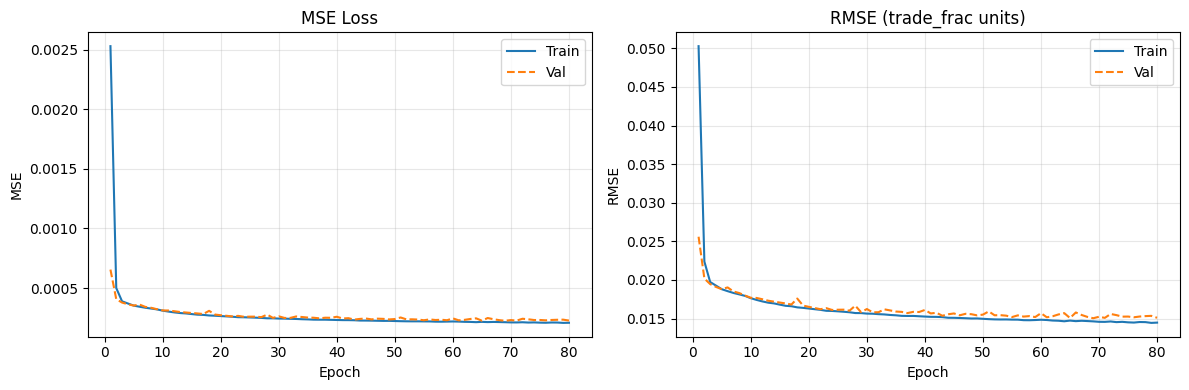

In [9]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Val", linestyle="--")
axes[0].set_title("MSE Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

train_rmse = [v**0.5 for v in history["train_loss"]]
val_rmse   = [v**0.5 for v in history["val_loss"]]
axes[1].plot(epochs_range, train_rmse, label="Train")
axes[1].plot(epochs_range, val_rmse,   label="Val", linestyle="--")
axes[1].set_title("RMSE (trade_frac units)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 7. Evaluation — Predictions vs Ground Truth

In [10]:
y_pred = np.array(model(X_val_j))
y_true = np.array(y_val_j)

mae  = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
r2   = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)

print(f"Validation metrics (trade_frac scale)")
print(f"  MAE  : {mae:.6f}")
print(f"  RMSE : {rmse:.6f}")
print(f"  R²   : {r2:.6f}")

Validation metrics (trade_frac scale)
  MAE  : 0.006770
  RMSE : 0.015098
  R²   : 0.579968


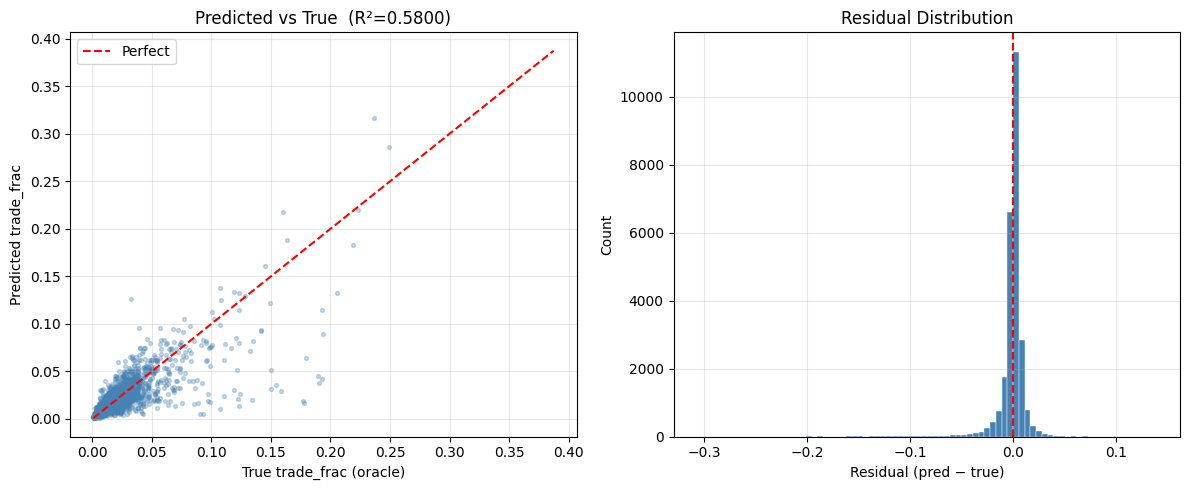

In [11]:
sample = min(3_000, len(y_true))
idx_s  = np.random.default_rng(0).choice(len(y_true), sample, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_true[idx_s], y_pred[idx_s], alpha=0.3, s=8, color="steelblue")
lims = [y_true.min(), y_true.max()]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect")
axes[0].set_xlabel("True trade_frac (oracle)")
axes[0].set_ylabel("Predicted trade_frac")
axes[0].set_title(f"Predicted vs True  (R²={r2:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_pred - y_true
axes[1].hist(residuals, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual (pred − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation.png", dpi=150)
plt.show()

## 8. Execution Simulation — DNN vs TWAP Baseline vs VWAP Baseline vs Oracle

Simulate a full parent-order execution over real bars and compare:
- **Oracle VWAP** (perfect hindsight — upper bound)
- **Naive TWAP** (trade equal slices — lower bound)
- **DNN** (our model's predicted schedule)

Metric: \$-cost slippage relative to market VWAP.

In [12]:
import sys, importlib
sys.path.insert(0, str(Path("..").resolve()))

# Reload the data generator to get access to bar-level data
import generate_vwap_data as gvd
importlib.reload(gvd)

lobster_dir = Path("..") / "LOBSTER_SampleFile_AAPL_2012-06-21_5"
messages, orderbook = gvd.load_lobster(lobster_dir)
bars = gvd.aggregate_bars(messages, orderbook, bar_seconds=60)

Loaded 301,587 events from AAPL_2012-06-21_34200000_57600000_message_5.csv
Aggregated into 390 bars (60s each)
  Total volume: 2,850,140 shares
  Avg volume/bar: 7,308 shares


In [13]:
def simulate_execution(bars_df, start_bar, horizon, parent_Q, model_fn=None):
    """Simulate a parent-order execution and return cost metrics.

    Parameters
    ----------
    bars_df    : DataFrame from aggregate_bars
    start_bar  : index of first bar in the execution window
    horizon    : number of bars (T)
    parent_Q   : total shares to execute
    model_fn   : callable(features) → trade_frac array; None = oracle VWAP

    Returns
    -------
    dict with execution metrics
    """
    end = start_bar + horizon
    window = bars_df.iloc[start_bar:end].copy()

    volume   = window["volume"].values.astype(np.float64)
    mid      = window["mid_price"].values.astype(np.float64)
    total_vol = volume.sum()

    # Market VWAP (benchmark price)
    if total_vol > 0:
        market_vwap = np.sum(volume * mid) / total_vol
    else:
        market_vwap = mid.mean()

    # ── Oracle schedule ──
    oracle_frac = volume / (total_vol + 1e-9)

    # ── TWAP schedule ──
    twap_frac = np.full(horizon, 1.0 / horizon)

    # ── DNN schedule ──
    if model_fn is not None:
        # Build the same features the model was trained on
        inv_remaining = np.ones(horizon, dtype=np.float64)
        schedule = np.zeros(horizon, dtype=np.float64)

        for t in range(horizon):
            bar_i = start_bar + t
            row = bars_df.iloc[bar_i]

            features = np.array([[
                inv_remaining[t] if t == 0 else 1.0 - schedule[:t].sum(),
                (horizon - t) / horizon,
                row["spread_bps"],
                row["mid_price_return"],
                row["order_imbalance_L1"],
                row["depth_imbalance_5L"],
                row["bid_depth_norm"],
                row["ask_depth_norm"],
                row["volume_rate_ratio"],
                row["volume_ma_short_ratio"],
            ]], dtype=np.float32)

            # Standardize using training stats
            features = (features - X_mean) / X_std
            pred = float(model_fn(jnp.array(features))[0])
            pred = np.clip(pred, 0.0, 1.0)
            schedule[t] = pred

        # Normalise schedule so it sums to 1 (must execute exactly Q)
        dnn_frac = schedule / (schedule.sum() + 1e-9)
    else:
        dnn_frac = None

    def execution_price(frac):
        """Weighted avg execution price given a schedule."""
        shares = frac * parent_Q
        return np.sum(shares * mid) / parent_Q

    results = {
        "market_vwap": market_vwap,
        "oracle_price": execution_price(oracle_frac),
        "twap_price": execution_price(twap_frac),
        "oracle_frac": oracle_frac,
        "twap_frac": twap_frac,
    }
    if dnn_frac is not None:
        results["dnn_price"] = execution_price(dnn_frac)
        results["dnn_frac"]  = dnn_frac

    return results

print("simulate_execution defined.")

simulate_execution defined.


In [15]:
# ── Run many simulated executions and compare strategies ──
rng_sim = np.random.default_rng(99)
n_trials = 200
parent_Q = 5_000.0

n_bars = len(bars)
results_list = []

for _ in range(n_trials):
    T = rng_sim.integers(10, 40)
    start = rng_sim.integers(0, n_bars - T)
    res = simulate_execution(bars, start, T, parent_Q, model_fn=model)
    results_list.append(res)

# ── Compute slippage vs market VWAP (in basis points) ──
oracle_slip = []
twap_slip   = []
dnn_slip    = []

for r in results_list:
    vwap = r["market_vwap"]
    # Slippage in bps (positive = worse for a sell order)
    oracle_slip.append((vwap - r["oracle_price"]) / vwap * 1e4)
    twap_slip.append((vwap - r["twap_price"]) / vwap * 1e4)
    dnn_slip.append((vwap - r["dnn_price"]) / vwap * 1e4)

oracle_slip = np.array(oracle_slip)
twap_slip   = np.array(twap_slip)
dnn_slip    = np.array(dnn_slip)

print(f"{'Strategy':<12} {'Mean Slip (bps)':>16} {'Std (bps)':>12} {'Median (bps)':>14}")
print("-" * 58)
for name, arr in [("Oracle", oracle_slip), ("TWAP", twap_slip), ("DNN", dnn_slip)]:
    print(f"{name:<12} {arr.mean():>16.4f} {arr.std():>12.4f} {np.median(arr):>14.4f}")

print(f"\nDNN improvement over TWAP: {(twap_slip.mean() - dnn_slip.mean()):.4f} bps")

Strategy      Mean Slip (bps)    Std (bps)   Median (bps)
----------------------------------------------------------
Oracle                 0.0000       0.0000         0.0000
TWAP                  -0.5530       1.5597        -0.3558
DNN                    0.0584       1.4167         0.1529

DNN improvement over TWAP: -0.6115 bps


/tmp/ipykernel_686266/4032980316.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=labels, patch_artist=True, showmeans=True)


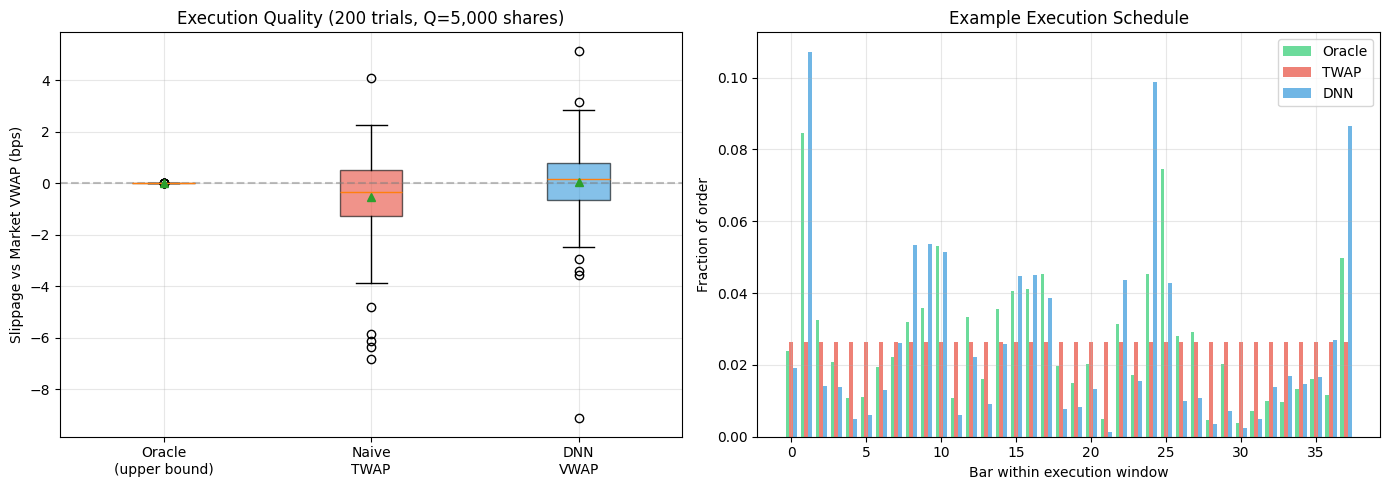

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Slippage comparison ──
data = [oracle_slip, twap_slip, dnn_slip]
labels = ["Oracle\n(upper bound)", "Naive\nTWAP", "DNN\nVWAP"]
bp = axes[0].boxplot(data, labels=labels, patch_artist=True, showmeans=True)
colors = ["#2ecc71", "#e74c3c", "#3498db"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Slippage vs Market VWAP (bps)")
axes[0].set_title(f"Execution Quality ({n_trials} trials, Q={parent_Q:,.0f} shares)")
axes[0].grid(True, alpha=0.3)

# ── Example schedule: DNN vs Oracle vs TWAP for one episode ──
ex = results_list[0]
x_bars = np.arange(len(ex["oracle_frac"]))
axes[1].bar(x_bars - 0.25, ex["oracle_frac"], width=0.25, label="Oracle", alpha=0.7, color="#2ecc71")
axes[1].bar(x_bars,        ex["twap_frac"],   width=0.25, label="TWAP",   alpha=0.7, color="#e74c3c")
axes[1].bar(x_bars + 0.25, ex["dnn_frac"],    width=0.25, label="DNN",    alpha=0.7, color="#3498db")
axes[1].set_xlabel("Bar within execution window")
axes[1].set_ylabel("Fraction of order")
axes[1].set_title("Example Execution Schedule")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("execution_comparison.png", dpi=150)
plt.show()

## 9. Single-Order Inference Demo

"Sell 5,000 shares of AAPL over the next 20 bars." Walk through the model's decisions step by step.

Task: Sell 5,000 shares over bars 100–149

  Market VWAP   : $585.3264
  Oracle price  : $585.3264
  TWAP price    : $585.3014
  Baseline price: $585.2760
  DNN price     : $585.3135

 Bar   Mid Price      Oracle        TWAP    Baseline         DNN
--------------------------------------------------------------
   0  $   585.89       110.6       100.0       100.0       160.6
   1  $   586.24       107.4       100.0       100.0        86.3
   2  $   585.98        77.9       100.0       100.0        86.3
   3  $   585.97       378.7       100.0       100.0       356.3
   4  $   585.36       145.9       100.0       100.0       134.1
   5  $   585.50       141.0       100.0       100.0        96.8
   6  $   585.74        96.2       100.0         0.0        77.5
   7  $   585.96        86.8       100.0       100.0        70.4
   8  $   586.08       159.0       100.0       100.0       126.8
   9  $   586.38        93.0       100.0       100.0        85.5
  10  $   586.29        46.2       100

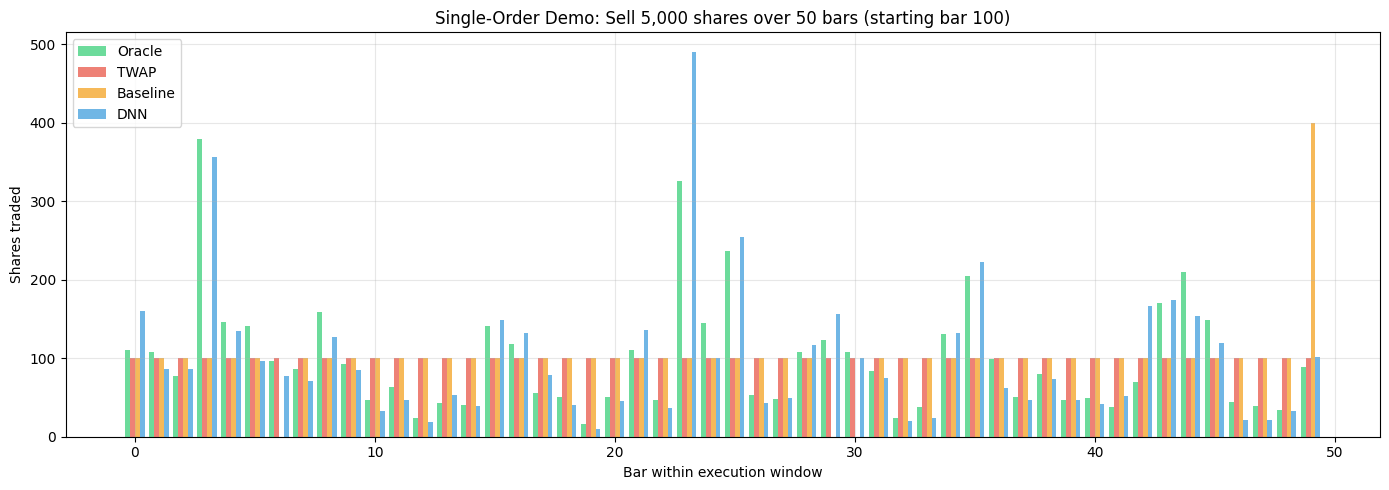

In [19]:
demo_start  = 100   # start at bar 100 (~11:10 AM)
demo_T      = 50
demo_Q      = 5_000

# ── DNN + Oracle + TWAP ──
res = simulate_execution(bars, demo_start, demo_T, demo_Q, model_fn=model)

# ── Baseline Agent ──
bl = simulate_baseline(bars, demo_start, demo_T, demo_Q, strategy="volume")

dnn_shares      = res['dnn_frac'] * demo_Q
oracle_shares   = res['oracle_frac'] * demo_Q
twap_shares     = res['twap_frac'] * demo_Q
baseline_shares = bl['baseline_frac'] * demo_Q

print(f"Task: Sell {demo_Q:,} shares over bars {demo_start}–{demo_start + demo_T - 1}")
print()
print(f"  Market VWAP   : ${res['market_vwap']:.4f}")
print(f"  Oracle price  : ${res['oracle_price']:.4f}")
print(f"  TWAP price    : ${res['twap_price']:.4f}")
print(f"  Baseline price: ${bl['baseline_price']:.4f}")
print(f"  DNN price     : ${res['dnn_price']:.4f}")
print()

print(f"{'Bar':>4}  {'Mid Price':>10}  {'Oracle':>10}  {'TWAP':>10}  {'Baseline':>10}  {'DNN':>10}")
print("-" * 62)
for i in range(demo_T):
    mid_i = bars.iloc[demo_start + i]['mid_price']
    print(f"{i:>4}  ${mid_i:>9.2f}  {oracle_shares[i]:>10.1f}  {twap_shares[i]:>10.1f}"
          f"  {baseline_shares[i]:>10.1f}  {dnn_shares[i]:>10.1f}")

print("-" * 62)
print(f"{'Tot':>4}  {'':>10}  {oracle_shares.sum():>10.1f}  {twap_shares.sum():>10.1f}"
      f"  {baseline_shares.sum():>10.1f}  {dnn_shares.sum():>10.1f}")

# ── Visual comparison ──
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(demo_T)
w = 0.2
ax.bar(x - 1.5*w, oracle_shares,   width=w, label="Oracle",   alpha=0.7, color="#2ecc71")
ax.bar(x - 0.5*w, twap_shares,     width=w, label="TWAP",     alpha=0.7, color="#e74c3c")
ax.bar(x + 0.5*w, baseline_shares, width=w, label="Baseline", alpha=0.7, color="#f39c12")
ax.bar(x + 1.5*w, dnn_shares,      width=w, label="DNN",      alpha=0.7, color="#3498db")
ax.set_xlabel("Bar within execution window")
ax.set_ylabel("Shares traded")
ax.set_title(f"Single-Order Demo: Sell {demo_Q:,} shares over {demo_T} bars (starting bar {demo_start})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("single_order_demo.png", dpi=150)
plt.show()

## 10. DNN vs Baseline Agent Comparison

Compare the VWAP DNN against the **BaselineAgent** (strategy="volume") from `baseline_agent.py`.

The baseline agent uses a heuristic volume-tracking approach: it estimates volume progress from recent
market activity and dispatches fixed-size batches accordingly. We run both strategies over the same
200 random execution windows and compare slippage vs market VWAP.

In [20]:
sys.path.insert(0, str(Path("../baseline_model").resolve()))
from baseline_agent import BaselineAgent

def simulate_baseline(bars_df, start_bar, horizon, parent_Q, strategy="volume"):
    """Run the BaselineAgent over a bar window and return an execution schedule.

    Each bar is treated as one 'step'. The agent decides per-bar how many
    batches to fire; shares are allocated proportionally.
    """
    end = start_bar + horizon
    window = bars_df.iloc[start_bar:end]

    volume = window["volume"].values.astype(np.float64)
    mid    = window["mid_price"].values.astype(np.float64)
    total_vol = volume.sum()

    # Market VWAP benchmark
    market_vwap = (np.sum(volume * mid) / total_vol) if total_vol > 0 else mid.mean()

    batch_size = max(1, int(parent_Q / horizon))  # ~equal batches across bars
    agent = BaselineAgent(
        strategy=strategy,
        total_qty=int(parent_Q),
        batch_size=batch_size,
        total_steps=horizon,
        use_limit_orders=False,
        aggression_factor=1.0,
    )

    shares_per_bar = np.zeros(horizon, dtype=np.float64)
    remaining = parent_Q
    cumulative_market_vol = 0

    for t in range(horizon):
        bar_i = start_bar + t
        cumulative_market_vol += int(volume[t])
        time_remaining_pct = (horizon - t - 1) / horizon

        prev_batches = agent.batches_executed
        agent.get_action(
            features={},
            remaining_qty=int(remaining),
            time_remaining_pct=time_remaining_pct,
            direction="sell",
            market_volume=cumulative_market_vol,
        )
        new_batches = agent.batches_executed - prev_batches
        traded = min(new_batches * batch_size, remaining)
        shares_per_bar[t] = traded
        remaining -= traded

    # If anything is left (rounding), dump it in the last bar
    if remaining > 0:
        shares_per_bar[-1] += remaining

    baseline_frac = shares_per_bar / parent_Q
    baseline_price = np.sum(baseline_frac * parent_Q * mid) / parent_Q

    return {
        "market_vwap": market_vwap,
        "baseline_price": baseline_price,
        "baseline_frac": baseline_frac,
    }

# ── Run baseline over the same 200 trials ──
rng_sim2 = np.random.default_rng(99)   # same seed → same windows
baseline_slip = []

for _ in range(n_trials):
    T = rng_sim2.integers(10, 40)
    start = rng_sim2.integers(0, n_bars - T)
    bl = simulate_baseline(bars, start, T, parent_Q, strategy="volume")
    slip = (bl["market_vwap"] - bl["baseline_price"]) / bl["market_vwap"] * 1e4
    baseline_slip.append(slip)

baseline_slip = np.array(baseline_slip)

print(f"{'Strategy':<16} {'Mean Slip (bps)':>16} {'Std (bps)':>12} {'Median (bps)':>14}")
print("-" * 62)
for name, arr in [
    ("Oracle",       oracle_slip),
    ("Naive TWAP",   twap_slip),
    ("Baseline VWAP", baseline_slip),
    ("DNN VWAP",     dnn_slip),
]:
    print(f"{name:<16} {arr.mean():>16.4f} {arr.std():>12.4f} {np.median(arr):>14.4f}")

print()
print(f"DNN improvement over Baseline: {(baseline_slip.mean() - dnn_slip.mean()):.4f} bps")
print(f"DNN improvement over TWAP:     {(twap_slip.mean() - dnn_slip.mean()):.4f} bps")

Strategy          Mean Slip (bps)    Std (bps)   Median (bps)
--------------------------------------------------------------
Oracle                     0.0000       0.0000         0.0000
Naive TWAP                -0.5530       1.5597        -0.3558
Baseline VWAP             -0.3635       1.4492        -0.2704
DNN VWAP                   0.0584       1.4167         0.1529

DNN improvement over Baseline: -0.4219 bps
DNN improvement over TWAP:     -0.6115 bps


/tmp/ipykernel_686266/2983894419.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=labels, patch_artist=True, showmeans=True)


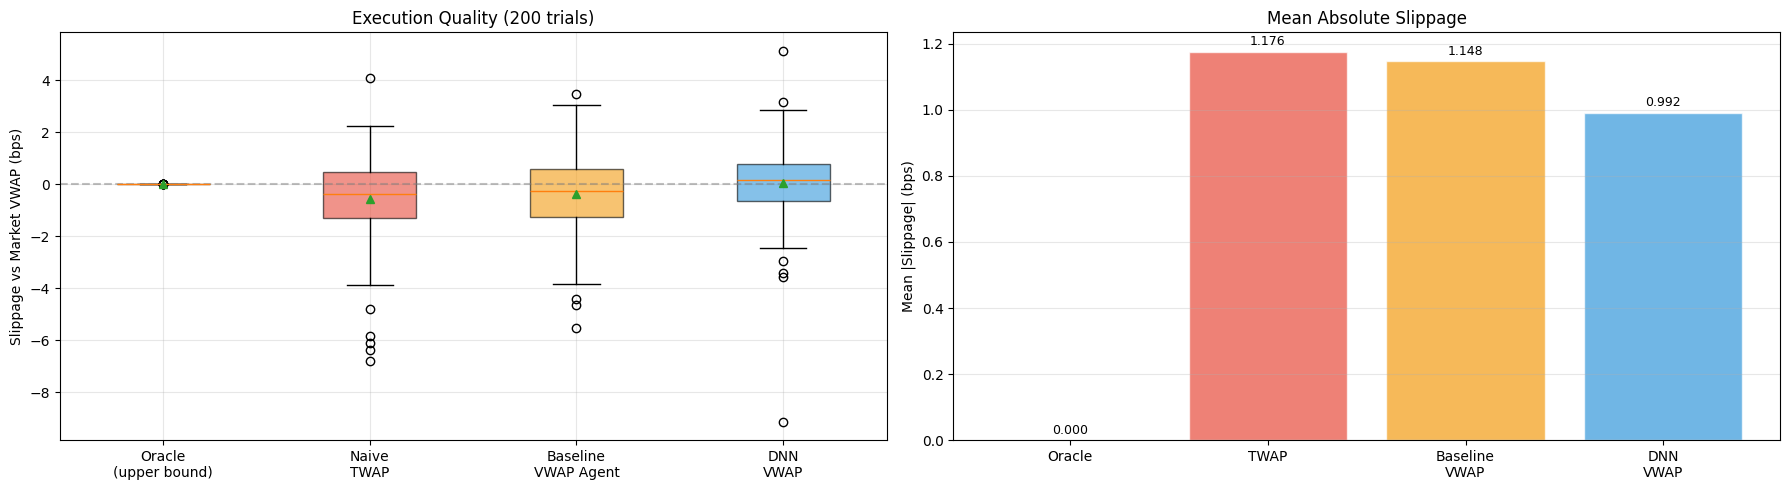

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── 1. Slippage boxplot: all four strategies ──
data = [oracle_slip, twap_slip, baseline_slip, dnn_slip]
labels = ["Oracle\n(upper bound)", "Naive\nTWAP", "Baseline\nVWAP Agent", "DNN\nVWAP"]
bp = axes[0].boxplot(data, labels=labels, patch_artist=True, showmeans=True)
colors = ["#2ecc71", "#e74c3c", "#f39c12", "#3498db"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_ylabel("Slippage vs Market VWAP (bps)")
axes[0].set_title(f"Execution Quality ({n_trials} trials)")
axes[0].grid(True, alpha=0.3)



# ── 2. Bar chart of mean |slippage| ──
means = [np.abs(oracle_slip).mean(), np.abs(twap_slip).mean(),
         np.abs(baseline_slip).mean(), np.abs(dnn_slip).mean()]
bar_labels = ["Oracle", "TWAP", "Baseline\nVWAP", "DNN\nVWAP"]
bar_colors = ["#2ecc71", "#e74c3c", "#f39c12", "#3498db"]
axes[1].bar(bar_labels, means, color=bar_colors, alpha=0.7, edgecolor="white")
axes[1].set_ylabel("Mean |Slippage| (bps)")
axes[1].set_title("Mean Absolute Slippage")
axes[1].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(means):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("dnn_vs_baseline_comparison.png", dpi=150)
plt.show()

Task: Sell 5,000 shares over bars 100–199

  Market VWAP   : $584.4916
  Oracle price  : $584.4916
  TWAP price    : $584.4301
  Baseline price: $584.3438
  DNN price     : $585.0718

 Bar   Mid Price      Oracle        TWAP    Baseline         DNN
--------------------------------------------------------------
   0  $   585.89        57.9        50.0        50.0        23.7
   1  $   586.24        56.2        50.0        50.0        13.0
   2  $   585.98        40.8        50.0        50.0        16.5
   3  $   585.97       198.3        50.0        50.0        44.2
   4  $   585.36        76.4        50.0        50.0        25.1
   5  $   585.50        73.8        50.0        50.0        21.6
   6  $   585.74        50.4        50.0         0.0        29.9
   7  $   585.96        45.4        50.0        50.0        14.3
   8  $   586.08        83.2        50.0        50.0        45.3
   9  $   586.38        48.7        50.0        50.0        79.7
  10  $   586.29        24.2        50

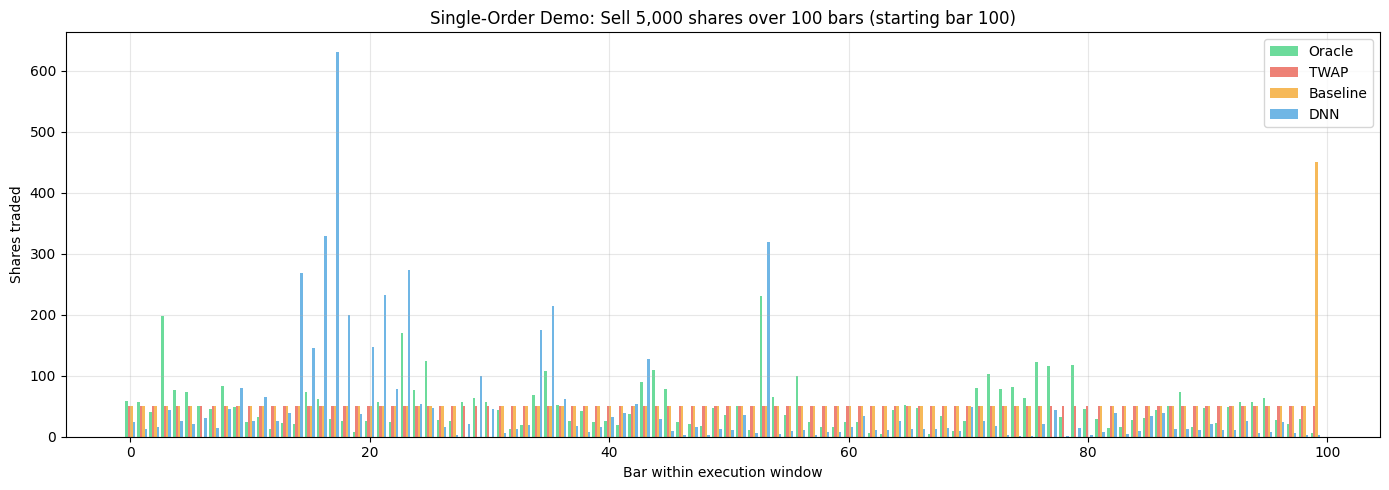

In [22]:
demo_start  = 100   # start at bar 100 (~11:10 AM)
demo_T      = 100
demo_Q      = 5_000

# ── DNN + Oracle + TWAP ──
res = simulate_execution(bars, demo_start, demo_T, demo_Q, model_fn=model)

# ── Baseline Agent ──
bl = simulate_baseline(bars, demo_start, demo_T, demo_Q, strategy="volume")

dnn_shares      = res['dnn_frac'] * demo_Q
oracle_shares   = res['oracle_frac'] * demo_Q
twap_shares     = res['twap_frac'] * demo_Q
baseline_shares = bl['baseline_frac'] * demo_Q

print(f"Task: Sell {demo_Q:,} shares over bars {demo_start}–{demo_start + demo_T - 1}")
print()
print(f"  Market VWAP   : ${res['market_vwap']:.4f}")
print(f"  Oracle price  : ${res['oracle_price']:.4f}")
print(f"  TWAP price    : ${res['twap_price']:.4f}")
print(f"  Baseline price: ${bl['baseline_price']:.4f}")
print(f"  DNN price     : ${res['dnn_price']:.4f}")
print()

print(f"{'Bar':>4}  {'Mid Price':>10}  {'Oracle':>10}  {'TWAP':>10}  {'Baseline':>10}  {'DNN':>10}")
print("-" * 62)
for i in range(demo_T):
    mid_i = bars.iloc[demo_start + i]['mid_price']
    print(f"{i:>4}  ${mid_i:>9.2f}  {oracle_shares[i]:>10.1f}  {twap_shares[i]:>10.1f}"
          f"  {baseline_shares[i]:>10.1f}  {dnn_shares[i]:>10.1f}")

print("-" * 62)
print(f"{'Tot':>4}  {'':>10}  {oracle_shares.sum():>10.1f}  {twap_shares.sum():>10.1f}"
      f"  {baseline_shares.sum():>10.1f}  {dnn_shares.sum():>10.1f}")

# ── Visual comparison ──
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(demo_T)
w = 0.2
ax.bar(x - 1.5*w, oracle_shares,   width=w, label="Oracle",   alpha=0.7, color="#2ecc71")
ax.bar(x - 0.5*w, twap_shares,     width=w, label="TWAP",     alpha=0.7, color="#e74c3c")
ax.bar(x + 0.5*w, baseline_shares, width=w, label="Baseline", alpha=0.7, color="#f39c12")
ax.bar(x + 1.5*w, dnn_shares,      width=w, label="DNN",      alpha=0.7, color="#3498db")
ax.set_xlabel("Bar within execution window")
ax.set_ylabel("Shares traded")
ax.set_title(f"Single-Order Demo: Sell {demo_Q:,} shares over {demo_T} bars (starting bar {demo_start})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("single_order_demo.png", dpi=150)
plt.show()

Task: Sell 5,000 shares over bars 200–249

  Market VWAP   : $583.3426
  Oracle price  : $583.3426
  TWAP price    : $583.2851
  Baseline price: $583.2143
  DNN price     : $583.3354

 Bar   Mid Price      Oracle        TWAP    Baseline         DNN
--------------------------------------------------------------
   0  $   582.92       133.7       100.0       100.0       163.2
   1  $   582.88        72.5       100.0       100.0        73.8
   2  $   582.86       192.2       100.0       100.0       162.5
   3  $   583.18       317.1       100.0       100.0       237.8
   4  $   583.80       118.7       100.0       100.0        73.0
   5  $   583.66       123.6       100.0       100.0        71.2
   6  $   583.50        20.4       100.0       100.0        24.6
   7  $   583.46        85.7       100.0       100.0        80.1
   8  $   583.23        16.8       100.0       100.0        13.0
   9  $   583.17        30.8       100.0       100.0        29.3
  10  $   583.25        42.7       100

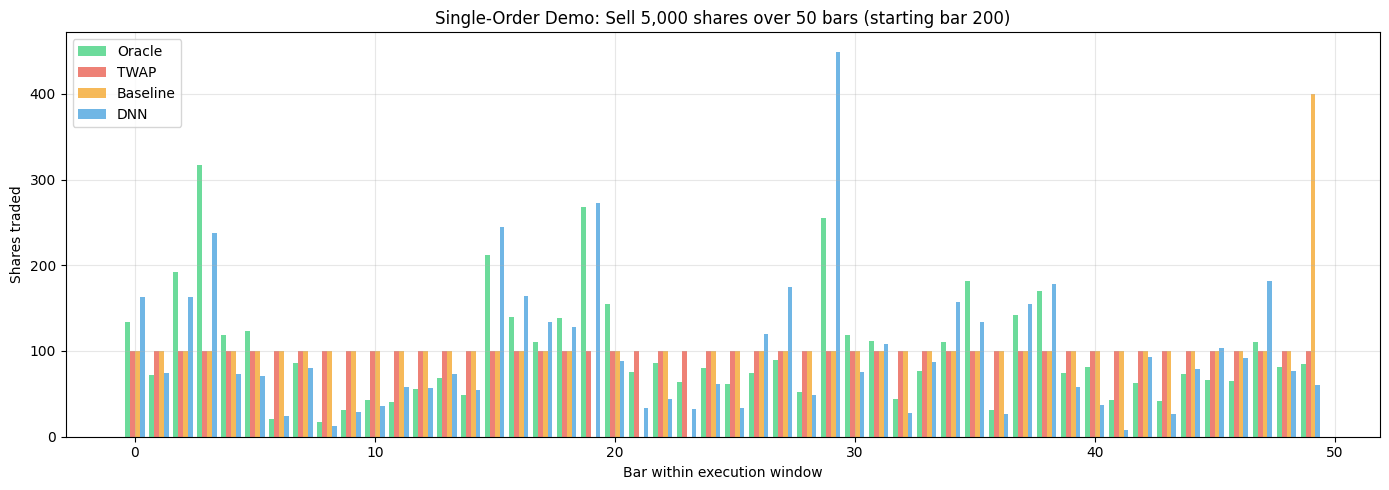

In [23]:
demo_start  = 200   # start at bar 100 (~11:10 AM)
demo_T      = 50
demo_Q      = 5_000

# ── DNN + Oracle + TWAP ──
res = simulate_execution(bars, demo_start, demo_T, demo_Q, model_fn=model)

# ── Baseline Agent ──
bl = simulate_baseline(bars, demo_start, demo_T, demo_Q, strategy="volume")

dnn_shares      = res['dnn_frac'] * demo_Q
oracle_shares   = res['oracle_frac'] * demo_Q
twap_shares     = res['twap_frac'] * demo_Q
baseline_shares = bl['baseline_frac'] * demo_Q

print(f"Task: Sell {demo_Q:,} shares over bars {demo_start}–{demo_start + demo_T - 1}")
print()
print(f"  Market VWAP   : ${res['market_vwap']:.4f}")
print(f"  Oracle price  : ${res['oracle_price']:.4f}")
print(f"  TWAP price    : ${res['twap_price']:.4f}")
print(f"  Baseline price: ${bl['baseline_price']:.4f}")
print(f"  DNN price     : ${res['dnn_price']:.4f}")
print()

print(f"{'Bar':>4}  {'Mid Price':>10}  {'Oracle':>10}  {'TWAP':>10}  {'Baseline':>10}  {'DNN':>10}")
print("-" * 62)
for i in range(demo_T):
    mid_i = bars.iloc[demo_start + i]['mid_price']
    print(f"{i:>4}  ${mid_i:>9.2f}  {oracle_shares[i]:>10.1f}  {twap_shares[i]:>10.1f}"
          f"  {baseline_shares[i]:>10.1f}  {dnn_shares[i]:>10.1f}")

print("-" * 62)
print(f"{'Tot':>4}  {'':>10}  {oracle_shares.sum():>10.1f}  {twap_shares.sum():>10.1f}"
      f"  {baseline_shares.sum():>10.1f}  {dnn_shares.sum():>10.1f}")

# ── Visual comparison ──
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(demo_T)
w = 0.2
ax.bar(x - 1.5*w, oracle_shares,   width=w, label="Oracle",   alpha=0.7, color="#2ecc71")
ax.bar(x - 0.5*w, twap_shares,     width=w, label="TWAP",     alpha=0.7, color="#e74c3c")
ax.bar(x + 0.5*w, baseline_shares, width=w, label="Baseline", alpha=0.7, color="#f39c12")
ax.bar(x + 1.5*w, dnn_shares,      width=w, label="DNN",      alpha=0.7, color="#3498db")
ax.set_xlabel("Bar within execution window")
ax.set_ylabel("Shares traded")
ax.set_title(f"Single-Order Demo: Sell {demo_Q:,} shares over {demo_T} bars (starting bar {demo_start})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("single_order_demo.png", dpi=150)
plt.show()